# Análisis de datos de las ocupaciones de A05

En este notebook se usan datos de la campaña A05 para hacer distintas representaciones teniendo en cuenta distintos aspectos del mismo. Se divide la estructura de forma que hay un conjunto de celdas para cada representación que se busca

## Importaciones previas y previsualización

In [1]:
# Importamos los paquetes necesarios
import numpy as np
import matplotlib.pyplot as plt
import cartopy 
import xarray as xr
import glob
import os
from scipy.interpolate import LinearNDInterpolator

In [21]:
ruta = "./Data/direct_downloads/A05/29AH20110128_ctd.nc"
ds = xr.open_dataset(ruta)

ds

<xarray.Dataset> Size: 28MB
Dimensions:             (N_PROF: 167, N_LEVELS: 3023)
Coordinates:
    expocode            (N_PROF) object 1kB ...
    station             (N_PROF) object 1kB ...
    cast                (N_PROF) int32 668B ...
    time                (N_PROF) datetime64[ns] 1kB ...
    latitude            (N_PROF) float64 1kB ...
    longitude           (N_PROF) float64 1kB ...
    sample              (N_PROF, N_LEVELS) object 4MB ...
    pressure            (N_PROF, N_LEVELS) float64 4MB ...
Dimensions without coordinates: N_PROF, N_LEVELS
Data variables:
    section_id          (N_PROF) object 1kB ...
    btm_depth           (N_PROF) float64 1kB ...
    pressure_qc         (N_PROF, N_LEVELS) float32 2MB ...
    ctd_temperature     (N_PROF, N_LEVELS) float64 4MB ...
    ctd_temperature_qc  (N_PROF, N_LEVELS) float32 2MB ...
    ctd_salinity        (N_PROF, N_LEVELS) float64 4MB ...
    ctd_salinity_qc     (N_PROF, N_LEVELS) float32 2MB ...
    ctd_oxygen_ml_l     (N_PROF, N_LEVELS) float64 4MB ...
    ctd_oxygen_ml_l_qc  (N_PROF, N_LEVELS) float32 2MB ...
    profile_type        (N_PROF) object 1kB ...
    geometry_container  float64 8B ...
Attributes:
    Conventions:               CF-1.8 CCHDO-1.0
    cchdo_software_version:    hydro 1.0.2.3
    cchdo_parameters_version:  params 0.1.21
    comments:                  CTD,20150223SIOODFADQ
    featureType:               profile

## Temperatura-Longitud-Presión

En esta sección se representa la temperatura en un mapa de calor frente a la longitud y la presión con diferentes métodos:
* Interpolación con pcolormesh: Da un perfil uniforme pero tiene la desventaja de que borra características geográficas del fondo marino debido a la interpolación
* Scatter: Útil para representar los datos en bruto
* Contour: Método por excelencia. Se debe de hacer unas transformaciones previas para representar, pero es un punto medio entre las representaciones anteriores.

In [3]:
# Importamos valores que nos interesan en arrays
lon = ds.longitude.to_numpy()
press = ds.pressure.to_numpy()
temp = ds.ctd_temperature.to_numpy()

### Interpolación con pcolormesh


A modo de resumen lo que hace está celda es crear una malla de puntos de latitud longitud sintética e interpolada a partir los datos en bruto. Una vez hecho esto, interpola la temperatura para esos nuevos puntos, y una vez tenemos una malla regular para cada variable, representamos. Como se comento, la interpolación hace que se pierdan ciertas caracteristicas, pero tiene la gran ventaja de que se sigue viendo algunas propiedades. Por ejemplo se ve la clara disminución de la temperatura con la profundidad, y como a mayor cercanía con la costa, menos es la profundidad. También se ve como las aguas del caribe(izquierda) son más calidas que las aguas de canarias. Sin embargo, presenta la desventaja de que elimina las características geográficas del fondo marino

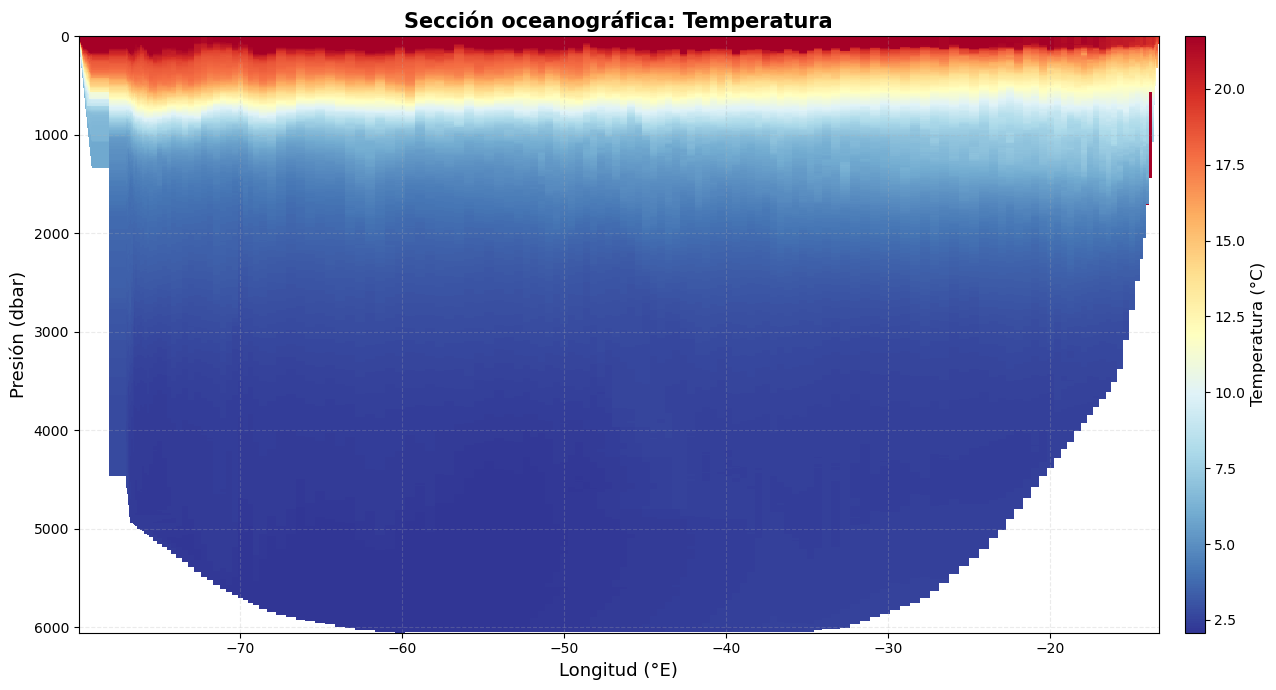

: 

: 

In [ ]:
# Extendemos longitud de (167,) a (167, 3032), para que tenga la misma forma que presión
lon_2d = np.tile(lon[:, None], (1, press.shape[1]))

# Creamos un índice booleano que elimine los valores nan de presión y temperatura
indice = ~np.isnan(press) & ~np.isnan(temp)

# Creamos los puntos que nos serviran luego para la interpolación
points = np.column_stack([lon_2d[indice], press[indice]]) # (N_valid, 2)
values = temp[indice]                                     # (N_valid,)

# Grid regular para la representación
p_common = np.linspace(np.nanmin(press), np.nanmax(press), 500)
LON, PRESS = np.meshgrid(lon, p_common, indexing = "ij") # (167, 500)

# Interpolamos la malla
interp = LinearNDInterpolator(points, values)
temp_grid = interp(LON, PRESS) # (167, 500)

# Pintamos
fig, ax = plt.subplots(figsize=(14,7))

pcm = ax.pcolormesh(LON, PRESS, temp_grid, cmap = 'RdYlBu_r', shading = 'auto', 
                    vmin = np.nanpercentile(temp_grid, 2), vmax = np.nanpercentile(temp_grid, 98))


cbar = fig.colorbar(pcm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Temperatura (°C)", fontsize=12)

ax.set_xlabel("Longitud (°E)", fontsize=13)
ax.set_ylabel("Presión (dbar)", fontsize=13)
ax.set_title("Sección oceanográfica: Temperatura", fontsize=15, fontweight="bold")
ax.invert_yaxis()
ax.grid(alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()


### Scatter

Muy similar a la anterior pero está si tiene en cuenta las carácterísticas geográficas y fallos en las medidas

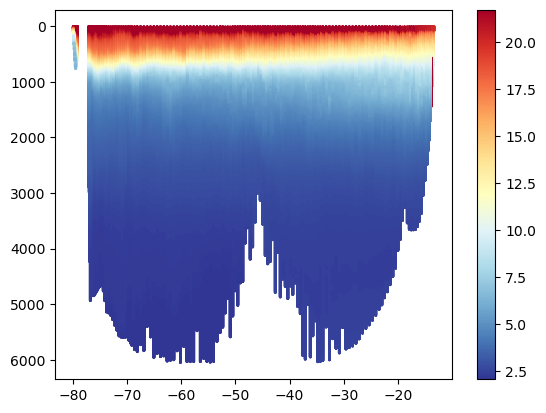

: 

: 

In [ ]:
lon_2d = np.tile(lon[:, None], (1, press.shape[1])) # Mismas dimensiones que temp y press

fig, ax = plt.subplots()
pcm = ax.scatter(lon_2d, press, c = temp , cmap = 'RdYlBu_r',
                 vmin = np.nanpercentile(temp_grid, 2), vmax = np.nanpercentile(temp_grid, 98), s = 1)
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

### Contour y Contourf

Este método permite además añadir las isotermas. Pero para ello, hay que hacer un análisis previo tanto de la calidad de los datos, como de las distribuciones de temperatura

#### Distribución de temperatura

Empleamos un histograma para representar los datos

(0.0, 30.0)

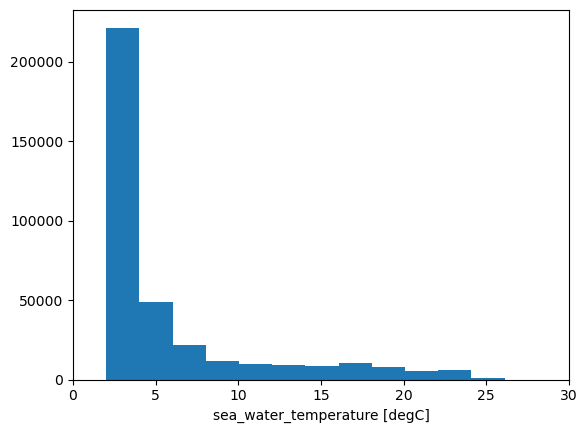

: 

: 

In [ ]:
ds.ctd_temperature.plot.hist(bins = 50)
plt.xlim(0, 30) # Hay datos con 99

Se ha recortado ya que hay valores con 99 que no fueron escritos como Nan, lo que da problemas y tendrá que ser recortado luego. Puede ser una buena aproximación dibujar 10 isotermas con diferencias de temperatura de 2.5 grados 

#### Análisis de la calidad de los datos

Para ver esto, se harán dos cosas:
* Representar los valores en un histograma
* Representarlos a color en un contour para identificar zonas problemáticas

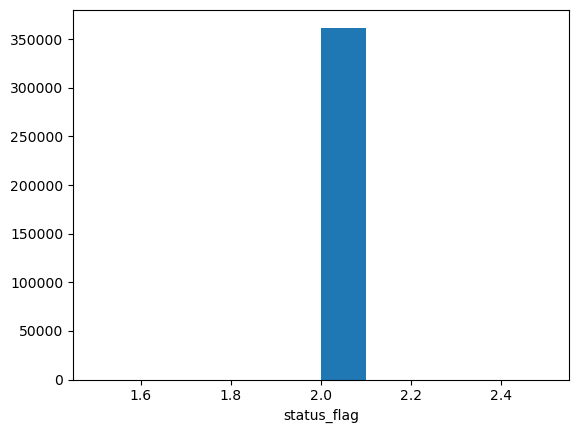

: 

: 

In [ ]:
# Representación histograma
ds.ctd_temperature_qc.plot.hist()
plt.show()

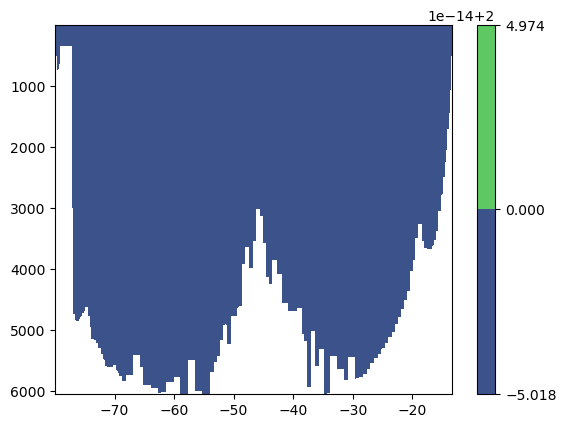

: 

: 

In [ ]:
# Representación a color
temp_qc = ds.ctd_temperature_qc.to_numpy()

index = ~np.isnan(press) & ~np.isnan(temp_qc)

P = press[index]
lon_2d = np.tile(lon[:, None], (1, press.shape[1]))

p = np.linspace(P.min(), P.max(), press.shape[1])
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T

fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, temp_qc)
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

De ambos, y según el código de calidad de datos de WOCE, no hay datos de mala calidad que deban ser descartados

#### Representación

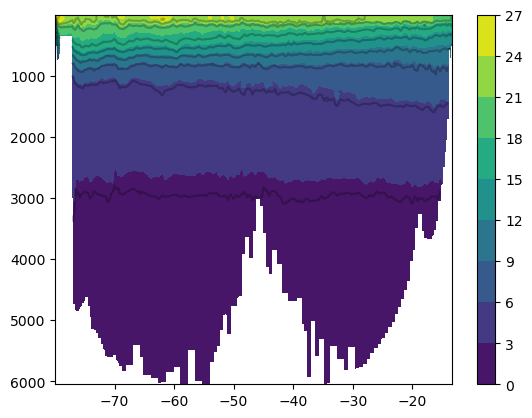

In [4]:
# Creamos un filtro para eliminar valores Nan de presión y además otro para eliminar los valores de t>90 
filtro   = ~np.isnan(press) 
ind = np.where(temp > 90)

# Corregimos la temperatura
temp[ind] = np.nan

# Aplicamos el filtro a la presión
P = press[filtro]

# Efectuamos la extensión de la longitud
lon_2d = np.tile(lon[:, None], (1, press.shape[1]))

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T


fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, temp)
ax.contour(lon_2d, PRESS, temp,colors = 'k',alpha = 0.25, levels = np.linspace(0, 25, 10))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

A continuación se realiza lo mismo para las variables de salinidad y oxígeno

## Salinidad-Longitud-Presión

### Análisis de distribución de datos

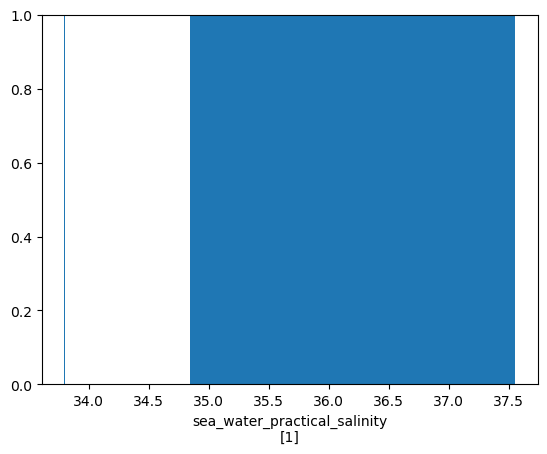

In [111]:
ds.ctd_salinity.plot.hist(bins = 500)

plt.ylim(0, 1)
plt.show()

Los datos se encuentran muy centrados en torno a 35, por lo que las líneas de igual salinidad se verán muy juntas. Resalta la presencia de algunos datos con valores inferiores a 10

### Análisis de la calidad de los datos

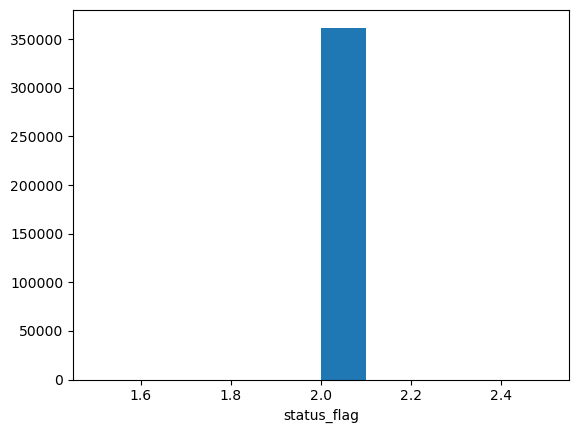

In [10]:
ds.ctd_salinity_qc.plot.hist()
plt.show()

Al igual que antes, todos los datos tienen buena calidad, por lo que no es necesario un filtro.

### Representación

In [113]:
salinity = ds.ctd_salinity.to_numpy()

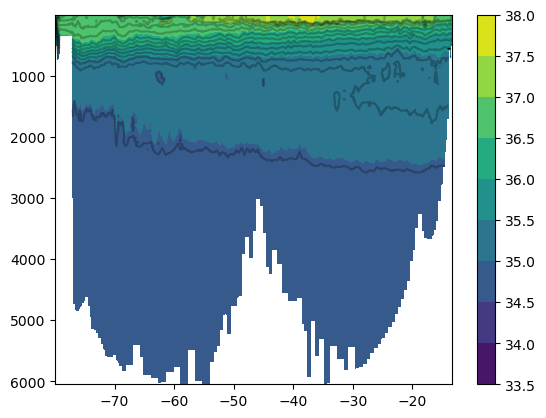

In [117]:
# Creamos un filtro para eliminar valores Nan de presión 
filtro   = ~np.isnan(press) 
index = np.where(salinity < 10)

# Aplicamos el filtro a la presión
P = press[filtro]

# Hacemos nan los valores que no tienen sentido
salinity[index] = np.nan

# Efectuamos la extensión de la longitud
lon_2d = np.tile(lon[:, None], (1, press.shape[1]))

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T

# Límites del color bar
vmin = np.nanmin(salinity)
vmax = np.nanmax(salinity)

fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, salinity)
ax.contour(lon_2d, PRESS, salinity ,colors = 'k',alpha = 0.25, 
           levels = np.linspace(vmin, vmax, 20))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

Como podemos ver este diagrama es muy parecido al de temperatura, lo que nos da a entender que efectivamente la salinidad y la temperatura están altamente relacionadas. Más adelante, haremos un diagrama TS, para visualizar está relación

## Oxígeno-Longitud-Presión

### Análisis de distribución de datos

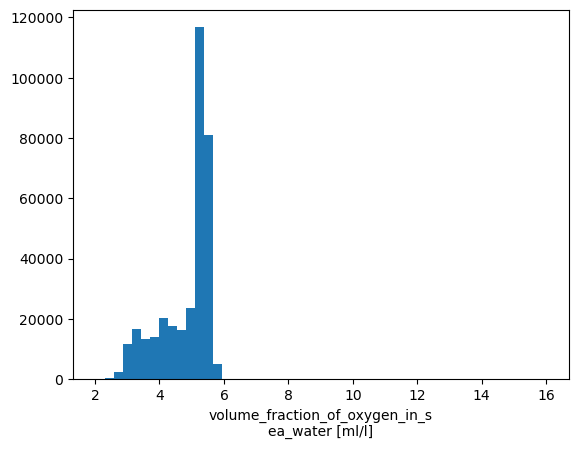

In [62]:
ds.ctd_oxygen_ml_l.plot.hist(bins = 50)
plt.show()

Hay datos que tienen valores de 16, posiblemente necesitan un filtrado. Con respecto a los datos más centrados, estos, parece ser que con 20 niveles se pillan bien las líneas con igual contenido en oxígeno

### Análisis de la calidad de los datos

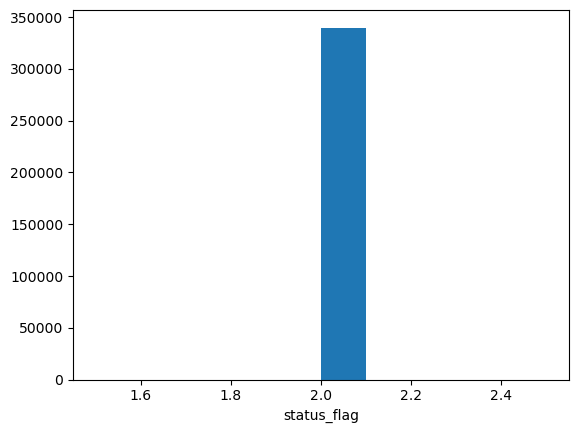

In [65]:
ds.ctd_oxygen_ml_l_qc.plot.hist()
plt.show()

Igual que en los casos anteriores, la calidad de los datos es buena, por lo que no es necesario aplicar ningún filtro extra

### Representación

In [79]:
# Importamos los datos en un array
oxygen = ds.ctd_oxygen_ml_l.to_numpy()

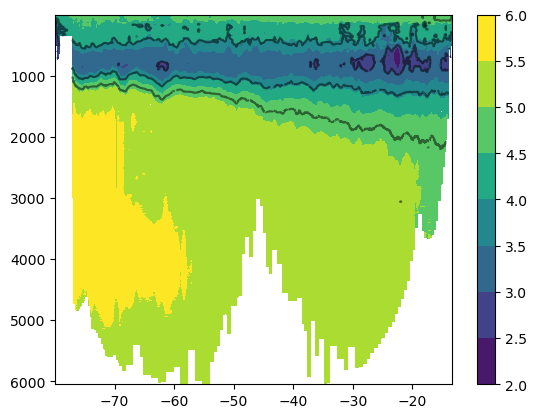

In [84]:
# Creamos un filtro para eliminar valores Nan de presión 
filtro   = ~np.isnan(press) 

# Aplicamos el filtro a la presión
P = press[filtro]

indice = np.where(oxygen > 10)
oxygen[indice] = np.nan
# Efectuamos la extensión de la longitud
lon_2d = np.tile(lon[:, None], (1, press.shape[1]))

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T

# Límites del color bar
vmin = np.nanmin(oxygen)
vmax = np.nanmax(oxygen)

fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, oxygen, vmin = vmin, vmax = vmax)
ax.contour(lon_2d, PRESS, oxygen ,colors = 'k',alpha = 0.5, 
           levels = np.linspace(vmin, vmax, 5))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

## Diagrama TS

Volvemos a trabajar con los datos de temperatura y salinidad, los cuales, al igual que antes tenemos que corregir, y simplemente representamos en un diagrama

In [103]:
salinity = ds.ctd_salinity.to_numpy()
temp = ds.ctd_temperature.to_numpy()

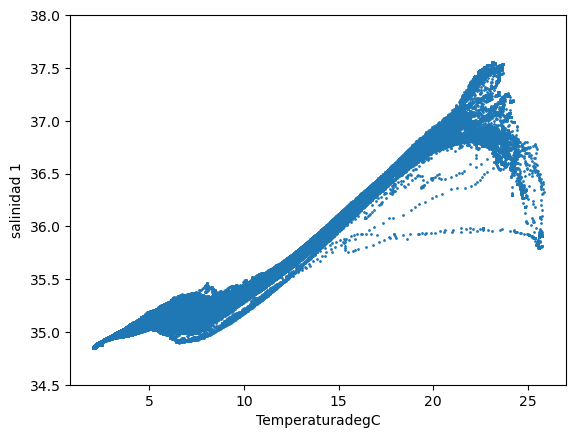

In [104]:
salt_index = np.where(salinity < 10)    
temp_index = np.where(temp > 90)

# Hacemos nan los valores que no tienen sentido
temp[temp_index] = np.nan
salinity[salt_index] = np.nan

filtro = ~np.isnan(temp) & ~np.isnan(salinity)

# Eliminamos los valores Nan
temp = temp[filtro]
salinity = salinity[filtro]

# Representamos
plt.scatter(temp, salinity, s = 1)
plt.xlabel('Temperatura' + ds.ctd_temperature.attrs['units'])
plt.ylabel('salinidad '+ds.ctd_salinity.attrs['units'])
plt.ylim(34.5, 38)
plt.show()

A priori parece estar bien